# CIGALE + MAF on 100,000 COSMOS2020 galaxies

The catalog, filters, noise convention, MAF context, and summary plots match the FSPS
tutorial. The physical model is deliberately native CIGALE: delayed-tau SFH, BC03,
nebular emission, modified-starburst attenuation, and redshifting/IGM attenuation.


In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys
import numpy as np

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "composed").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
DATA_PATH = REPO_ROOT / "notebooks/tutorials/data/cosmos2020_ugrizYJH_100k.npz"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 00_prepare_cosmos2020_ugrizYJH.ipynb first.")

with np.load(DATA_PATH, allow_pickle=False) as catalog:
    flux = catalog["flux_maggies"]
    sigma = catalog["sigma_maggies"]
    z_reference = catalog["lp_zbest"]
    mass_reference = catalog["lp_mass_med"]
    sfr_reference = catalog["lp_sfr_med"]
    dust_reference = catalog["lp_dust"]
    BAND_NAMES = tuple(catalog["band_names"].astype(str))
    FILTER_NAMES = tuple(catalog["sedpy_filter_names"].astype(str))
    SINGLE_OBJECT = int(catalog["single_object_position"])

print(f"Loaded {flux.shape[0]:,} galaxies in {flux.shape[1]} bands")
print("Single tutorial object:", SINGLE_OBJECT, "z_ref=", z_reference[SINGLE_OBJECT])

from sedpy.observate import load_filters
from composed.filters import FilterSet

filters = FilterSet(load_filters(list(FILTER_NAMES)), names=BAND_NAMES)


Loaded 100,000 galaxies in 8 bands
Single tutorial object: 36096 z_ref= 1.0001


## Model and priors


In [2]:
from composed import DelayedTauSFH, EmpiricalPhotometricNoise, Gaussian, Problem, SEDDataset, UniformPrior
from composed.backends.cigale import build_cigale_backend_and_parameter_space

sfh = DelayedTauSFH(age="age_fraction", age_kind="fraction_of_universe", tau="tau_gyr")
modules = ["bc03", "nebular", "dustatt_modified_starburst", "redshifting"]
module_parameters = {
    "bc03": {"imf": 1, "metallicity": 0.02, "separation_age": 10},
    "nebular": {
        "logU": -2.0, "zgas": 0.019, "ne": 100.0, "f_esc": 0.0,
        "f_dust": 0.0, "lines_width": 300.0, "emission": True,
    },
    "dustatt_modified_starburst": {
        "E_BV_lines": {"range": [0.0, 0.8]}, "E_BV_factor": 0.44,
        "uv_bump_wavelength": 217.5, "uv_bump_width": 35.0,
        "uv_bump_amplitude": 0.0, "powerlaw_slope": 0.0,
        "Ext_law_emission_lines": 1, "Rv": 3.1, "filters": "B_B90 & V_B90",
    },
    "redshifting": {"redshift": {"range": [0.05, 5.0]}},
}
backend, parameters = build_cigale_backend_and_parameter_space(
    modules,
    module_parameters,
    additional_priors={
        "log10_mass": UniformPrior(6.0, 13.0),
        "age_fraction": UniformPrior(0.30, 0.95),
        "tau_gyr": UniformPrior(0.1, 8.0),
    },
    sfh=sfh,
    photometry_mode="sedpy",
    default_z_key="redshift",
)
noise_model = EmpiricalPhotometricNoise(
    sigma, fractional_error=0.0, band_names=BAND_NAMES, flux_unit="maggies"
)
data = SEDDataset(BAND_NAMES, flux[SINGLE_OBJECT], sigma[SINGLE_OBJECT], flux_unit="maggies")
problem = Problem(backend, parameters, data, Gaussian(), filters=filters)


In [3]:
from composed import MAF, PhotometricContext, Simulate, fit

QUICK = os.environ.get("COMPOSED_TUTORIAL_QUICK", "0") == "1"
N_TRAIN = 2_000 if QUICK else 300_000
N_TARGET = 512 if QUICK else flux.shape[0]
if QUICK and SINGLE_OBJECT >= N_TARGET:
    TARGET_INDICES = np.concatenate([np.arange(N_TARGET - 1), [SINGLE_OBJECT]])
else:
    TARGET_INDICES = np.arange(N_TARGET)
SINGLE_SUMMARY_POSITION = int(np.flatnonzero(TARGET_INDICES == SINGLE_OBJECT)[0])
N_POSTERIOR = 32 if QUICK else 128
N_SINGLE_DRAWS = 512 if QUICK else 30_000
EPOCHS = 10 if QUICK else 500
N_WORKERS = min(8, os.cpu_count() or 1)
OUTPUT = REPO_ROOT / "outputs/tutorial_cigale_maf_cosmos2020"
CHECKPOINT = OUTPUT / "maf"
OUTPUT.mkdir(parents=True, exist_ok=True)

t0 = time.perf_counter()
# One call generates the simulations, trains the MAF, and samples this galaxy.
maf_single = fit(
    problem,
    MAF(
        hidden_features=256, num_transforms=6, num_blocks=3, epochs=EPOCHS,
        batch_size=2048, validation_split=0.1, patience=None, device="auto",
        num_samples=N_SINGLE_DRAWS, inference_batch_size=8192,
    ),
    training=Simulate(
        n=N_TRAIN, noise_fn=noise_model, infer=parameters.names,
        context=PhotometricContext("snr_logsigma", flux_unit="maggies"),
        n_workers=N_WORKERS, batch_size=128, executor="process", mp_context="spawn",
        max_retries=max(1000, N_TRAIN // 5),
    ),
    seed=52,
)
print(f"End-to-end SBI fit: {time.perf_counter() - t0:.1f} s")
posterior = maf_single.inference_state
posterior.save(CHECKPOINT, overwrite=True)
print("MAF device:", posterior.estimator.device)


End-to-end SBI fit: 2983.2 s
MAF device: mps


## Batched catalog inference


In [4]:
t0 = time.perf_counter()
summary = posterior.summarize_catalog(
    flux[TARGET_INDICES], sigma=sigma[TARGET_INDICES], input_units="native",
    num_samples=N_POSTERIOR, batch_size=8192, seed=53,
)
inference_seconds = time.perf_counter() - t0
summary.save(OUTPUT / "catalog_summary.npz")
print(f"{N_TARGET:,} galaxies x {N_POSTERIOR} draws in {inference_seconds:.2f} s")
print(f"{N_TARGET * N_POSTERIOR / inference_seconds:,.0f} posterior draws/s")


100,000 galaxies x 128 draws in 89.78 s
142,570 posterior draws/s


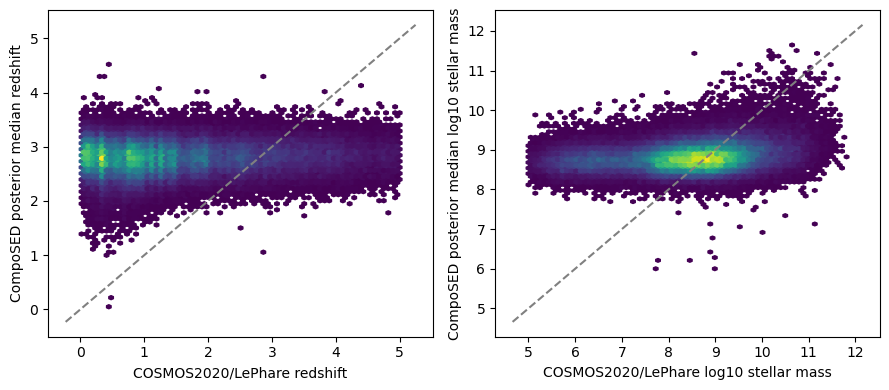

In [5]:
z_index = posterior.theta_names.index("redshift")
mass_index = posterior.theta_names.index("log10_mass")
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].hexbin(z_reference[TARGET_INDICES], summary.median[:, z_index], gridsize=70, mincnt=1)
axes[1].hexbin(mass_reference[TARGET_INDICES], summary.median[:, mass_index], gridsize=70, mincnt=1)
for ax, name in zip(axes, ("redshift", "log10 stellar mass")):
    lo, hi = ax.get_xlim(); ax.plot([lo, hi], [lo, hi], "--", color="0.5")
    ax.set(xlabel=f"COSMOS2020/LePhare {name}", ylabel=f"CompoSED posterior median {name}")
fig.tight_layout()


## MAF posterior for the single-galaxy comparison

This is the same COSMOS2020 galaxy and the same CIGALE model fitted with TAMIS in
`03_cigale_tamis_single_galaxy.ipynb`. We retain 30,000 raw MAF draws here so the
learned posterior geometry can be inspected directly.


MAF posterior medians: {'log10_mass': 9.047434827976216, 'age_fraction': 0.6258843893719191, 'tau_gyr': 3.841284144066695, 'E_BV_lines': 0.4297182738143636, 'redshift': 2.337597343769324}
LePhare comparison: z= 1.0001 logM= 10.00341


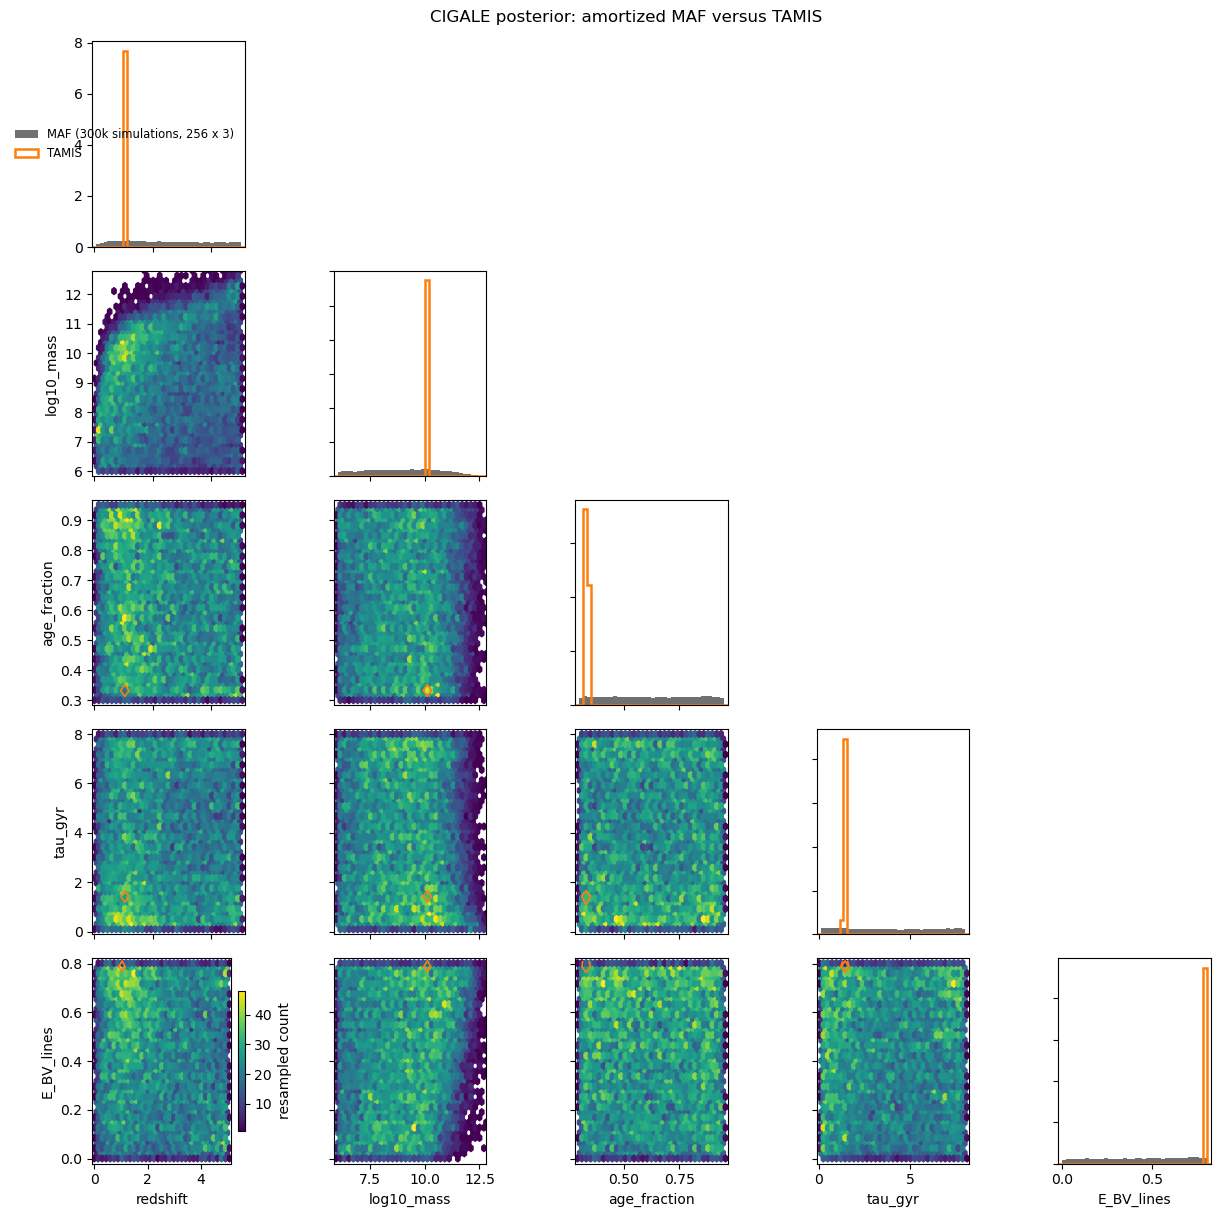

In [6]:
from composed import load_inference_result
from composed.plot import plot_corner_hexbin

reference_path = REPO_ROOT / "outputs/tutorial_cigale_tamis_single"
reference_mc = load_inference_result(reference_path) if reference_path.exists() else None
if reference_mc is None:
    print("Run 03_cigale_tamis_single_galaxy.ipynb to add the TAMIS contours.")

corner_parameters = ["redshift", "log10_mass", "age_fraction", "tau_gyr", "E_BV_lines"]
fig, _ = plot_corner_hexbin(
    maf_single,
    parameters=corner_parameters,
    comparison_result=reference_mc,
    result_label="MAF (300k simulations, 256 x 3)",
    comparison_label="TAMIS",
    max_points=N_SINGLE_DRAWS,
    seed=55,
)
fig.suptitle("CIGALE posterior: amortized MAF versus TAMIS", y=1.01)
fig.savefig(OUTPUT / "single_object_maf_vs_tamis_corner.png", dpi=160, bbox_inches="tight")
print("MAF posterior medians:", dict(zip(posterior.theta_names, maf_single.posterior_median)))
print("LePhare comparison: z=", z_reference[SINGLE_OBJECT], "logM=", mass_reference[SINGLE_OBJECT])


posterior-median log10 SFR: 0.4006771887684272
LePhare reference log10 SFR: 1.09896


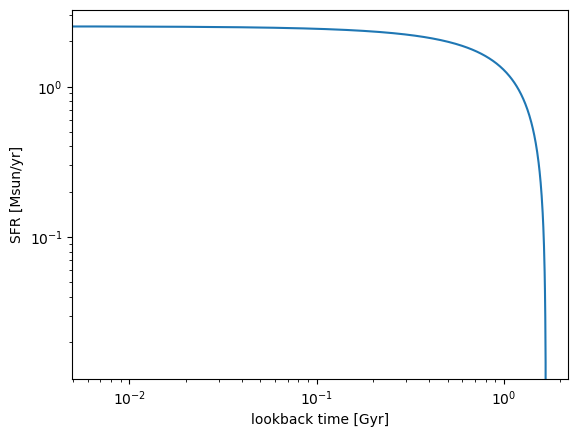

In [7]:
from composed import derive_sfh_quantities

median_params = dict(zip(posterior.theta_names, summary.median[SINGLE_SUMMARY_POSITION]))
derived = derive_sfh_quantities(backend, median_params, filters)
lookback = derived.time_gyr[-1] - derived.time_gyr
plt.plot(lookback[::-1], derived.sfr_msun_per_yr[::-1])
plt.xscale("log"); plt.yscale("log")
plt.xlabel("lookback time [Gyr]"); plt.ylabel("SFR [Msun/yr]")
print("posterior-median log10 SFR:", derived.log10_sfr)
print("LePhare reference log10 SFR:", sfr_reference[SINGLE_OBJECT])
